# Instance-wise Center Loss - quick start

Official PyTorch implementation of *Instance-wise Center Loss for Efficient Training of Deep Convolutional Neural Networks* (IEEE GCCE 2022) - [paper](https://ieeexplore.ieee.org/document/10014037) | [code](https://github.com/MADONOKOUKI/gcce2022_instancewise_center_loss) | [project page](https://madonokouki.github.io/projects/instance-center-loss/)

Every training image is augmented N times; besides the cross-entropy, the logits of each view are pulled towards the mean logits of the views of the *same* image (its instance centre). The notebook runs on a CPU and downloads no data.

In [1]:
# Install the package when running on Google Colab (locally: pip install -e . in the repository)
import subprocess, sys
if "google.colab" in sys.modules:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "git+https://github.com/MADONOKOUKI/gcce2022_instancewise_center_loss"], check=True)

## 1. Drop-in use

`InstanceWiseCenterLoss` takes the logits of the N views, shape `(N, B, num_classes)`, and the labels; `alpha` is the weight lambda_IC of the paper. `make_views` turns a batch into N augmented views with any per-image augmentation.

In [2]:
import torch
from torchvision import transforms as T
import iwcl
from iwcl.models import build_model

model = build_model("resnet18", num_classes=10)            # returns (logits, features)
criterion = iwcl.InstanceWiseCenterLoss(alpha=0.7)             # lambda_IC = 0.7 for ResNet-18 (paper)
augment = T.Compose([T.RandomCrop(32, padding=4), T.RandomHorizontalFlip()])

images, labels = torch.rand(8, 3, 32, 32), torch.randint(0, 10, (8,))
views = iwcl.make_views(images, augment, num_views=2)           # (N, B, 3, 32, 32)
logits = torch.stack([model(v)[0] for v in views])              # (N, B, 10)
loss = criterion(logits, labels)
loss.backward()
print(criterion, "->", round(loss.item(), 4))

InstanceWiseCenterLoss(alpha=0.7, distance='mse', stopgrad=True, reduction='mean', center_on='logits') -> 0.742


## 2. Toy experiment

The same code as `examples/quickstart.py`: a tiny CNN is trained on synthetic 16x16 images with N=4 views, once with cross-entropy on the views only and once with the instance-wise center loss (lambda_IC=0.5, L2 distance, stop-gradient). The views of each held-out image are then plotted in logit space. This illustrates the idea on synthetic data; it is not a result of the paper.

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms as T

import iwcl

NUM_CLASSES, SIZE, NUM_VIEWS, BATCH = 4, 16, 4, 32  # NUM_VIEWS = N


def make_data(n: int, generator: torch.Generator):
    """Smooth random 16x16 RGB images: class template + image-specific pattern + noise."""
    templates = F.interpolate(torch.rand(NUM_CLASSES, 3, 4, 4, generator=torch.Generator().manual_seed(0)), size=SIZE, mode="bilinear")
    labels = torch.randint(0, NUM_CLASSES, (n,), generator=generator)
    own = F.interpolate(torch.rand(n, 3, 4, 4, generator=generator), size=SIZE, mode="bilinear")
    noise = 0.1 * torch.randn(n, 3, SIZE, SIZE, generator=generator)
    return (0.5 * templates[labels] + 0.5 * own + noise).clamp(0, 1), labels


class TinyCNN(nn.Module):
    def __init__(self) -> None:
        super().__init__()
        self.body = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.AdaptiveAvgPool2d(1), nn.Flatten(),
        )
        self.fc = nn.Linear(32, NUM_CLASSES)

    def forward(self, x):
        return self.fc(self.body(x))


# a random augmentation of one image tensor (3, H, W); make_views calls it per image and view
augment = T.Compose([
    T.RandomCrop(SIZE, padding=3, padding_mode="reflect"),
    T.RandomHorizontalFlip(),
    T.RandomErasing(p=0.5, scale=(0.05, 0.2), value=0.5),
])


@torch.no_grad()
def view_logits(model, images, num_views: int = 24, seed: int = 1):
    """Logits of ``num_views`` fixed random views of every image: (views, images, classes)."""
    was_training = model.training
    model.eval()
    with torch.random.fork_rng():  # the same views for every call, without touching the training RNG
        torch.manual_seed(seed)
        z = torch.stack([model(v) for v in iwcl.make_views(images, augment, num_views)])
    model.train(was_training)
    return z


def relative_spread(z: torch.Tensor) -> float:
    """Variance of the views around their instance centre / total variance of the logits."""
    within = (z - z.mean(0, keepdim=True)).pow(2).sum(-1).mean()
    total = (z - z.mean((0, 1), keepdim=True)).pow(2).sum(-1).mean()
    return (within / total).item()


def train(use_iwcl: bool, images, labels, probe, steps: int = 300, seed: int = 0):
    torch.manual_seed(seed)
    model = TinyCNN()
    optimizer = torch.optim.SGD(model.parameters(), lr=0.05, momentum=0.9)
    if use_iwcl:
        criterion = iwcl.InstanceWiseCenterLoss(alpha=0.5)                   # the paper's loss, lambda_IC = 0.5
    else:
        criterion = iwcl.MultiViewCrossEntropy()                               # CE on the same views
    history = []
    for step in range(1, steps + 1):
        idx = torch.randint(0, len(images), (BATCH,))
        views = iwcl.make_views(images[idx], augment, num_views=NUM_VIEWS)   # (N, B, 3, H, W)
        logits = torch.stack([model(v) for v in views])                      # (N, B, C)
        loss = criterion(logits, labels[idx])
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if step % 25 == 0:
            history.append((step, relative_spread(view_logits(model, probe, num_views=8))))
    return model.eval(), history


def main(out: Path, steps: int = 300) -> dict:
    g = torch.Generator().manual_seed(0)
    train_x, train_y = make_data(512, g)
    test_x, test_y = make_data(512, g)

    results = {}
    for name, use_iwcl in [("cross-entropy on N views", False), ("+ instance-wise center loss", True)]:
        model, history = train(use_iwcl, train_x, train_y, test_x[:64], steps)
        with torch.no_grad():
            acc = (model(test_x).argmax(1) == test_y).float().mean().item() * 100
        z = view_logits(model, test_x[:64])
        results[name] = dict(z=z, acc=acc, spread=relative_spread(z), history=history)
        print(f"{name:28s} test acc {acc:5.1f}%  relative view spread {results[name]['spread']:.3f}")

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
    colors = plt.cm.tab10.colors
    for ax, (name, r) in zip(axes[:2], results.items()):
        shown = r["z"][:, :8]                                      # 8 held-out images x 24 views
        flat = shown.reshape(-1, shown.size(-1))
        mean = flat.mean(0)
        _, _, v = torch.pca_lowrank(flat - mean, q=2, center=False)
        pts = (shown - mean) @ v[:, :2]                            # (views, 8, 2)
        centers = pts.mean(0)
        for i in range(pts.size(1)):
            c = colors[i % 10]
            for k in range(pts.size(0)):
                ax.plot([pts[k, i, 0], centers[i, 0]], [pts[k, i, 1], centers[i, 1]], color=c, lw=0.5, alpha=0.35)
            ax.scatter(pts[:, i, 0], pts[:, i, 1], s=12, color=c, alpha=0.8)
            ax.scatter(centers[i, 0], centers[i, 1], s=160, marker="*", color=c, edgecolor="black", linewidth=0.8, zorder=3)
        ax.set_title(f"{name}\ntest acc {r['acc']:.1f}%, relative view spread {r['spread']:.3f}", fontsize=10)
        ax.set_xlabel("logit PC 1")
        ax.set_ylabel("logit PC 2")
    for (name, r), color in zip(results.items(), ["#7f7f7f", "#d62728"]):
        s, h = zip(*r["history"])
        axes[2].plot(s, h, marker="o", ms=3, color=color, label=name)
    axes[2].set_xlabel("training step")
    axes[2].set_ylabel("within-image / total logit variance")
    axes[2].set_title("relative view spread on 64 held-out images\n(lower = views of an image agree)", fontsize=10)
    axes[2].legend()
    fig.suptitle("Toy example: views (dots) of the same image are pulled to their instance centre (star)", fontsize=12)
    fig.tight_layout()
    out.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out, dpi=110)
    print(f"saved {out}")
    return results


cross-entropy on N views     test acc  93.2%  relative view spread 0.104


+ instance-wise center loss  test acc  95.1%  relative view spread 0.078


saved quickstart.png


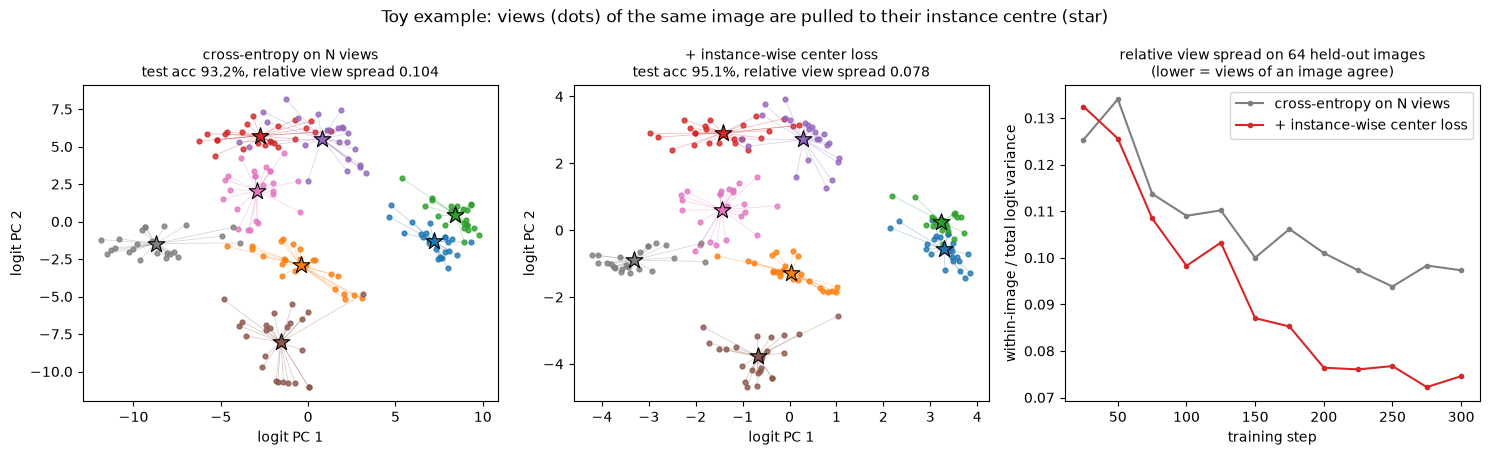

In [4]:
results = main(Path("quickstart.png"))
plt.show()